# **Load the data**

## 1. Load the dataset

This section imports the data into the notebook. The matching source code is in `src/data_processing.py`.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/raw/RTA Dataset.csv')
df


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,...,Other,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury


## 2. Inspect and clean the data

These cells review the dataset, identify missing values, remove selected columns, and drop incomplete rows.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [4]:
df.isnull().sum() # Check for missing values

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [5]:
# Remove columns with many missing values to retain more rows.
columns_to_drop = ['Defect_of_vehicle', 'Service_year_of_vehicle',
    'Fitness_of_casuality', 'Work_of_casuality'
]
df = df.drop(columns=columns_to_drop)

In [6]:
df.dropna(inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8439 entries, 1 to 12315
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         8439 non-null   object
 1   Day_of_week                  8439 non-null   object
 2   Age_band_of_driver           8439 non-null   object
 3   Sex_of_driver                8439 non-null   object
 4   Educational_level            8439 non-null   object
 5   Vehicle_driver_relation      8439 non-null   object
 6   Driving_experience           8439 non-null   object
 7   Type_of_vehicle              8439 non-null   object
 8   Owner_of_vehicle             8439 non-null   object
 9   Area_accident_occured        8439 non-null   object
 10  Lanes_or_Medians             8439 non-null   object
 11  Road_allignment              8439 non-null   object
 12  Types_of_Junction            8439 non-null   object
 13  Road_surface_type            8439 non

In [8]:
df.isnull().sum()

Time                           0
Day_of_week                    0
Age_band_of_driver             0
Sex_of_driver                  0
Educational_level              0
Vehicle_driver_relation        0
Driving_experience             0
Type_of_vehicle                0
Owner_of_vehicle               0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Vehicle_movement               0
Casualty_class                 0
Sex_of_casualty                0
Age_band_of_casualty           0
Casualty_severity              0
Pedestrian_movement            0
Cause_of_accident              0
Accident_severity              0
dtype: int64

In [9]:
df

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Area_accident_occured,...,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Pedestrian_movement,Cause_of_accident,Accident_severity
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,Office areas,...,2,2,Going straight,na,na,na,na,Not a Pedestrian,Overtaking,Slight Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Office areas,...,2,2,Going straight,Pedestrian,Female,18-30,3,Not a Pedestrian,Changing lane to the right,Slight Injury
7,17:20:00,Friday,18-30,Male,Junior high school,Employee,2-5yr,Automobile,Governmental,Residential areas,...,2,1,U-Turn,na,na,na,na,Not a Pedestrian,No priority to vehicle,Slight Injury
8,17:20:00,Friday,18-30,Male,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,Industrial areas,...,2,1,Going straight,Pedestrian,Male,Under 18,3,Crossing from driver's nearside,Changing lane to the right,Slight Injury
9,17:20:00,Friday,18-30,Male,Junior high school,Employee,1-2yr,Automobile,Owner,Residential areas,...,2,1,U-Turn,Passenger,Male,18-30,3,Not a Pedestrian,Moving Backward,Serious Injury
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12309,9:05:00,Friday,31-50,Female,Elementary school,Employee,5-10yr,Pick up upto 10Q,Owner,School areas,...,2,2,Going straight,Driver or rider,Male,18-30,3,Not a Pedestrian,Driving to the left,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,Outside rural areas,...,2,1,Other,na,na,na,na,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,Outside rural areas,...,1,1,Other,Driver or rider,Male,31-50,3,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,Office areas,...,2,1,Other,na,na,na,na,Not a Pedestrian,Driving under the influence of drugs,Slight Injury


## 4. Save the processed dataset

The cleaned dataset is exported as a CSV file for later use.

In [10]:
from pathlib import Path

output_path = Path('../data/processed/RTA Dataset cleaned.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)

print(f'Saved processed data to: {output_path}')

Saved processed data to: ../data/processed/RTA Dataset cleaned.csv


## 5. Encode categorical variables

Categorical values are converted to numerical labels so the models can use them.

In [11]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
label_mappings = {}

for column in categorical_cols:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    label_mappings[column] = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

# Encode text values as numbers, including Accident_severity.
print('Accident severity label mapping:', label_mappings['Accident_severity'])

Accident severity label mapping: {'Fatal injury': np.int64(0), 'Serious Injury': np.int64(1), 'Slight Injury': np.int64(2)}


## 6. Explore relationships and class balance

The following cells visualize feature correlations and inspect the target-class distribution.

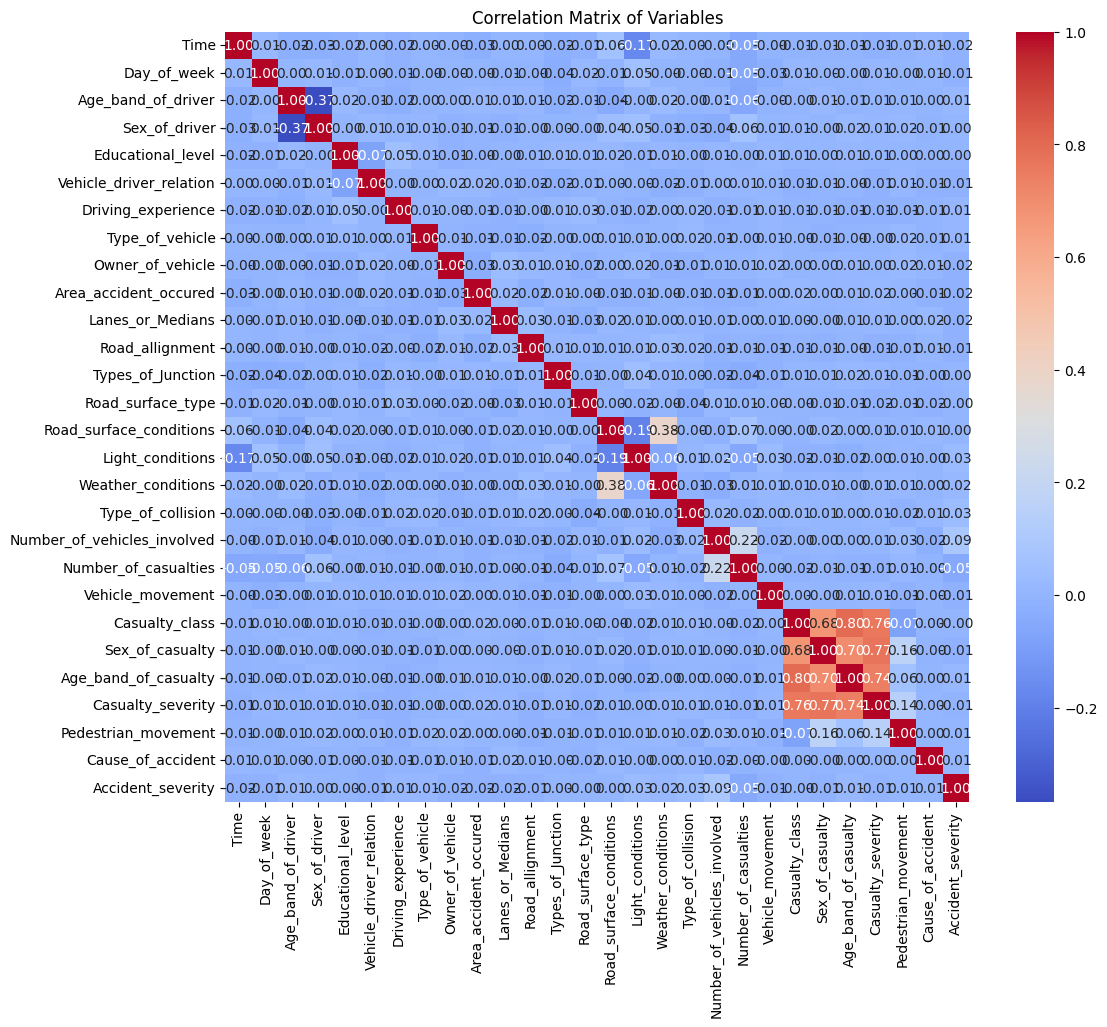

In [12]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# You can also visualize the correlation matrix using a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Variables')
plt.show()


In [13]:
df['Accident_severity'].value_counts()

Accident_severity
2    7169
1    1171
0      99
Name: count, dtype: int64

# **Random oversampling results**

The experiments use an 80% training split and a 20% test split. The selected features are defined in `SELECTED_FEATURES`.

## 7. Model experiments

The project compares Decision Tree, Random Forest, and XGBoost using multiple resampling approaches and 10-fold validation.

In [14]:
# prompt: K-Fold
from imblearn.over_sampling import RandomOverSampler
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Use one shared feature set in every model experiment.
SELECTED_FEATURES = [
    'Area_accident_occured', 'Day_of_week', 'Lanes_or_Medians',
    'Road_surface_conditions', 'Age_band_of_driver', 'Light_conditions',
    'Type_of_vehicle', 'Number_of_casualties', 'Cause_of_accident',
    'Number_of_vehicles_involved', 'Age_band_of_casualty',
    'Driving_experience', 'Type_of_collision'
]

n_splits = 10

# Stratification keeps the accident-severity class ratio similar in every fold.
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

decisiontree

### Random oversampling — Decision Tree

This experiment applies random oversampling to the training portion of each fold before fitting a Decision Tree.

In [15]:
# Lists to store evaluation metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

X = df[SELECTED_FEATURES]
y = df['Accident_severity']
# Loop through each fold
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Apply RandomOverSampler to the training data of the current fold
    ros = RandomOverSampler(random_state=42)
    X_train_fold, y_train_fold = ros.fit_resample(X_train, y_train)

    # Initialize and train your model (e.g., RandomForestClassifier)
    model = DecisionTreeClassifier() # Or any other classifier
    model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store metrics
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    print('classification report:', classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

# Calculate and print the average metrics across all folds
print("\nAverage Metrics across all folds:")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1-score: {np.mean(f1_scores):.4f}")

Fold 1
classification report:               precision    recall  f1-score   support

           0       0.09      0.10      0.10        10
           1       0.16      0.18      0.17       117
           2       0.85      0.83      0.84       717

    accuracy                           0.73       844
   macro avg       0.37      0.37      0.37       844
weighted avg       0.75      0.73      0.74       844

Accuracy: 0.7346
Precision: 0.7487
Recall: 0.7346
F1-score: 0.7414
Fold 2
classification report:               precision    recall  f1-score   support

           0       0.22      0.20      0.21        10
           1       0.19      0.18      0.18       117
           2       0.86      0.86      0.86       717

    accuracy                           0.76       844
   macro avg       0.42      0.41      0.42       844
weighted avg       0.76      0.76      0.76       844

Accuracy: 0.7618
Precision: 0.7571
Recall: 0.7618
F1-score: 0.7595
Fold 3
classification report:               

/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEst

classification report:               precision    recall  f1-score   support

           0       0.11      0.10      0.11        10
           1       0.21      0.21      0.21       117
           2       0.86      0.86      0.86       717

    accuracy                           0.76       844
   macro avg       0.39      0.39      0.39       844
weighted avg       0.76      0.76      0.76       844

Accuracy: 0.7607
Precision: 0.7621
Recall: 0.7607
F1-score: 0.7614
Fold 8
classification report:               precision    recall  f1-score   support

           0       0.07      0.10      0.08        10
           1       0.17      0.17      0.17       117
           2       0.86      0.85      0.85       717

    accuracy                           0.75       844
   macro avg       0.36      0.37      0.37       844
weighted avg       0.75      0.75      0.75       844

Accuracy: 0.7476
Precision: 0.7523
Recall: 0.7476
F1-score: 0.7499
Fold 9
classification report:               precisi

/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEst

randomforest

### Random oversampling — Random Forest

This experiment evaluates Random Forest with random oversampling.

In [16]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

X = df[SELECTED_FEATURES]
y = df['Accident_severity']

# Loop through each fold
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Apply RandomOverSampler to the training data of the current fold
    ros = RandomOverSampler(random_state=42)
    X_train_fold, y_train_fold = ros.fit_resample(X_train, y_train)

    # Initialize and train your model (e.g., RandomForestClassifier)
    model = RandomForestClassifier() # Or any other classifier
    model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store metrics
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print('classification report:', classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

# Calculate and print the average metrics across all folds
print("\nAverage Metrics across all folds:")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1-score: {np.mean(f1_scores):.4f}")

Fold 1


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       1.00      0.20      0.33        10
           1       0.33      0.05      0.09       117
           2       0.86      0.98      0.92       717

    accuracy                           0.85       844
   macro avg       0.73      0.41      0.45       844
weighted avg       0.79      0.85      0.79       844

Accuracy: 0.8460
Precision: 0.7859
Recall: 0.8460
F1-score: 0.7947
Fold 2


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.67      0.20      0.31        10
           1       0.41      0.06      0.10       117
           2       0.86      0.98      0.92       717

    accuracy                           0.85       844
   macro avg       0.65      0.41      0.44       844
weighted avg       0.79      0.85      0.80       844

Accuracy: 0.8472
Precision: 0.7929
Recall: 0.8472
F1-score: 0.7965
Fold 3


...

classification report:               precision    recall  f1-score   support

           0       0.50      0.10      0.17        10
           1       0.50      0.07      0.12       117
           2       0.86      0.99      0.92       717

    accuracy                           0.85       844
   macro avg       0.62      0.39      0.40       844
weighted avg       0.80      0.85      0.80       844

Accuracy: 0.8507
Precision: 0.8044
Recall: 0.8507
F1-score: 0.7994
Fold 8


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       1.00      0.10      0.18        10
           1       0.47      0.07      0.12       117
           2       0.86      0.99      0.92       717

    accuracy                           0.85       844
   macro avg       0.78      0.39      0.41       844
weighted avg       0.81      0.85      0.80       844

Accuracy: 0.8495
Precision: 0.8052
Recall: 0.8495
F1-score: 0.7983
Fold 9


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/taiku/Documents/road-accidents-severity-predic

classification report:               precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.41      0.09      0.15       117
           2       0.86      0.98      0.91       717

    accuracy                           0.84       844
   macro avg       0.42      0.36      0.36       844
weighted avg       0.79      0.84      0.80       844

Accuracy: 0.8436
Precision: 0.7854
Recall: 0.8436
F1-score: 0.7976
Fold 10
classification report:               precision    recall  f1-score   support

           0       1.00      0.11      0.20         9
           1       0.69      0.09      0.16       118
           2       0.86      0.99      0.92       716

    accuracy                           0.86       843
   macro avg       0.85      0.40      0.43       843
weighted avg       0.84      0.86      0.81       843

Accuracy: 0.8577
Precision: 0.8380
Recall: 0.8577
F1-score: 0.8084

Average Metrics across all folds:
Average Accurac

### Feature importance

This cell ranks input variables according to the fitted Random Forest model.

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Use the features and target defined in the previous step.
model = RandomForestClassifier(
    n_estimators=300, random_state=42, class_weight='balanced'
)
model.fit(X, y)

# Random Forest provides an importance score for each feature.
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display the five features that contribute most to the model predictions.
top5 = feature_importance_df.head(5)
top5

,Feature,Importance
8,Cause_of_accident,0.122504
1,Day_of_week,0.108481
6,Type_of_vehicle,0.107159
7,Number_of_casualties,0.091093
0,Area_accident_occured,0.090770


XGBoost

### Random oversampling — XGBoost

This experiment evaluates XGBoost with random oversampling.

In [18]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

X = df[SELECTED_FEATURES]
y = df['Accident_severity']


# Loop through each fold
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Apply RandomOverSampler to the training data of the current fold
    ros = RandomOverSampler(random_state=42)
    X_train_fold, y_train_fold = ros.fit_resample(X_train, y_train)


    # Initialize and train your model (e.g., RandomForestClassifier)
    model = xgb.XGBClassifier() # Or any other classifier
    model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store metrics
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print('classification report:', classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

# Calculate and print the average metrics across all folds
print("\nAverage Metrics across all folds:")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1-score: {np.mean(f1_scores):.4f}")

Fold 1


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.33      0.20      0.25        10
           1       0.27      0.29      0.28       117
           2       0.87      0.86      0.87       717

    accuracy                           0.78       844
   macro avg       0.49      0.45      0.47       844
weighted avg       0.78      0.78      0.78       844

Accuracy: 0.7773
Precision: 0.7819
Recall: 0.7773
F1-score: 0.7793
Fold 2


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.13      0.20      0.16        10
           1       0.22      0.25      0.23       117
           2       0.87      0.84      0.85       717

    accuracy                           0.75       844
   macro avg       0.41      0.43      0.41       844
weighted avg       0.77      0.75      0.76       844

Accuracy: 0.7500
Precision: 0.7674
Recall: 0.7500
F1-score: 0.7583
Fold 3


...

classification report:               precision    recall  f1-score   support

           0       0.20      0.20      0.20        10
           1       0.26      0.31      0.28       117
           2       0.87      0.85      0.86       717

    accuracy                           0.77       844
   macro avg       0.45      0.45      0.45       844
weighted avg       0.78      0.77      0.77       844

Accuracy: 0.7678
Precision: 0.7815
Recall: 0.7678
F1-score: 0.7743
Fold 9


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.18      0.24      0.21       117
           2       0.86      0.83      0.84       717

    accuracy                           0.74       844
   macro avg       0.35      0.36      0.35       844
weighted avg       0.76      0.74      0.74       844

Accuracy: 0.7358
Precision: 0.7556
Recall: 0.7358
F1-score: 0.7449
Fold 10


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.17      0.11      0.13         9
           1       0.22      0.25      0.23       118
           2       0.87      0.85      0.86       716

    accuracy                           0.76       843
   macro avg       0.42      0.40      0.41       843
weighted avg       0.77      0.76      0.77       843

Accuracy: 0.7616
Precision: 0.7698
Recall: 0.7616
F1-score: 0.7655

Average Metrics across all folds:
Average Accuracy: 0.7567
Average Precision: 0.7717
Average Recall: 0.7567
Average F1-score: 0.7635


# **Random undersampling results**

The experiments use the shared `SELECTED_FEATURES` list and stratified 10-fold cross-validation.

## 8. Random undersampling experiments

This section compares the model approaches under the notebook’s undersampling workflow.

In [19]:
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

# Define the number of folds
n_splits = 10  # You can change this value

# Initialize StratifiedKFold
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

decisiontree

### Random undersampling — Decision Tree

In [20]:
# Lists to store evaluation metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
X = df[SELECTED_FEATURES]
y = df['Accident_severity']

# Split the data while preserving the class distribution in each fold.
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f"Fold {fold + 1}")

    # Select the training and test data for the current fold.
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Initialise and train the baseline model without sampling.
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train_fold, y_train_fold)

    # Predict labels for the current fold test set.
    y_pred = model.predict(X_test_fold)

    # Uncomment these checks to inspect the prediction and label shapes.
    # print(f"Test labels shape: {y_test_fold.shape}")
    # print(f"Predicted labels shape: {y_pred.shape}")

    # Calculate evaluation metrics.
    accuracy = accuracy_score(y_test_fold, y_pred)
    precision = precision_score(y_test_fold, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test_fold, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_fold, y_pred, average='weighted', zero_division=0)

    # Store the metrics for this fold.
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print(f"Accuracy: {accuracy:.4f} | F1: {f1:.4f}")
    # Uncomment the following line to display a report for each fold.
    # print(classification_report(y_test_fold, y_pred))

# Summarise the average results.
print("\n" + "="*30)
print("AVERAGE METRICS (BASELINE 10-FOLD)")
print("="*30)
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1-score: {np.mean(f1_scores):.4f}")

Fold 1
Accuracy: 0.7488 | F1: 0.7612
Fold 2
Accuracy: 0.7382 | F1: 0.7477
Fold 3
Accuracy: 0.7476 | F1: 0.7572
Fold 4
Accuracy: 0.7429 | F1: 0.7493
Fold 5
Accuracy: 0.7251 | F1: 0.7412
Fold 6
Accuracy: 0.7192 | F1: 0.7333
Fold 7
Accuracy: 0.7464 | F1: 0.7573
Fold 8
Accuracy: 0.7512 | F1: 0.7616
Fold 9
Accuracy: 0.7322 | F1: 0.7434
Fold 10
Accuracy: 0.7521 | F1: 0.7588

AVERAGE METRICS (BASELINE 10-FOLD)
Average Accuracy: 0.7404
Average Precision: 0.7632
Average Recall: 0.7404
Average F1-score: 0.7511


randomforest

### Random undersampling — Random Forest

In [21]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

X = df[SELECTED_FEATURES]
y = df['Accident_severity']

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Initialize Model
    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(X_train_fold, y_train_fold)

    # Predict
    y_pred = rf_model.predict(X_test_fold)

    # Collect Metrics
    accuracy_scores.append(accuracy_score(y_test_fold, y_pred))
    precision_scores.append(precision_score(y_test_fold, y_pred, average='weighted', zero_division=0))
    recall_scores.append(recall_score(y_test_fold, y_pred, average='weighted', zero_division=0))
    f1_scores.append(f1_score(y_test_fold, y_pred, average='weighted', zero_division=0))

    print(f"Fold {fold + 1} completed")

print("\n--- Random Forest Average Results ---")
print(f"Avg Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Avg F1-score: {np.mean(f1_scores):.4f}")

Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed
Fold 6 completed
Fold 7 completed
Fold 8 completed
Fold 9 completed
Fold 10 completed

--- Random Forest Average Results ---
Avg Accuracy: 0.8531
Avg F1-score: 0.7930


XGBoost

### Random undersampling — XGBoost

In [22]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

X = df[SELECTED_FEATURES]
y = df['Accident_severity']


# Loop through each fold
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Apply RandomUnderSampler to the training data of the current fold
    rus = RandomUnderSampler(random_state=42)
    X_train_fold, y_train_fold = rus.fit_resample(X_train, y_train)

    # Initialize and train your model (e.g., RandomForestClassifier)
    model = xgb.XGBClassifier() # Or any other classifier
    model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store metrics
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print('classification report:', classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

# Calculate and print the average metrics across all folds
print("\nAverage Metrics across all folds:")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1-score: {np.mean(f1_scores):.4f}")

Fold 1


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.04      0.70      0.07        10
           1       0.17      0.44      0.24       117
           2       0.88      0.41      0.56       717

    accuracy                           0.42       844
   macro avg       0.36      0.52      0.29       844
weighted avg       0.77      0.42      0.51       844

Accuracy: 0.4194
Precision: 0.7695
Recall: 0.4194
F1-score: 0.5105
Fold 2


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.04      0.80      0.08        10
           1       0.14      0.35      0.20       117
           2       0.86      0.43      0.57       717

    accuracy                           0.42       844
   macro avg       0.35      0.53      0.28       844
weighted avg       0.75      0.42      0.51       844

Accuracy: 0.4206
Precision: 0.7546
Recall: 0.4206
F1-score: 0.5145
Fold 3


...

classification report:               precision    recall  f1-score   support

           0       0.02      0.40      0.04        10
           1       0.16      0.44      0.23       117
           2       0.88      0.42      0.57       717

    accuracy                           0.43       844
   macro avg       0.35      0.42      0.28       844
weighted avg       0.77      0.43      0.52       844

Accuracy: 0.4254
Precision: 0.7705
Recall: 0.4254
F1-score: 0.5181
Fold 9


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.03      0.50      0.05        10
           1       0.14      0.35      0.20       117
           2       0.84      0.44      0.58       717

    accuracy                           0.43       844
   macro avg       0.34      0.43      0.28       844
weighted avg       0.73      0.43      0.52       844

Accuracy: 0.4265
Precision: 0.7327
Recall: 0.4265
F1-score: 0.5170
Fold 10


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.02      0.33      0.03         9
           1       0.15      0.40      0.22       118
           2       0.85      0.42      0.56       716

    accuracy                           0.42       843
   macro avg       0.34      0.38      0.27       843
weighted avg       0.74      0.42      0.51       843

Accuracy: 0.4152
Precision: 0.7436
Recall: 0.4152
F1-score: 0.5082

Average Metrics across all folds:
Average Accuracy: 0.4264
Average Precision: 0.7583
Average Recall: 0.4264
Average F1-score: 0.5194


#**Smote**

#k=10

## 9. SMOTE experiments

This section applies SMOTE to the training data within each validation fold.

In [23]:
# prompt: K-Fold
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

# Define the number of folds
n_splits = 10  # You can change this value

# Initialize StratifiedKFold
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

DecisionTree

### SMOTE — Decision Tree

In [24]:
# Lists to store evaluation metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

X = df[SELECTED_FEATURES]
y = df['Accident_severity']
# Loop through each fold
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Apply SMOTE to the training data of the current fold
    smote = SMOTE(random_state=42)
    X_train_fold, y_train_fold = smote.fit_resample(X_train, y_train)

    # Initialize and train your model (e.g., RandomForestClassifier)
    model = DecisionTreeClassifier() # Or any other classifier
    model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store metrics
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    print('classification report:', classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

# Calculate and print the average metrics across all folds
print("\nAverage Metrics across all folds:")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1-score: {np.mean(f1_scores):.4f}")

Fold 1
classification report:               precision    recall  f1-score   support

           0       0.08      0.20      0.11        10
           1       0.16      0.28      0.21       117
           2       0.86      0.74      0.80       717

    accuracy                           0.67       844
   macro avg       0.37      0.41      0.37       844
weighted avg       0.75      0.67      0.71       844

Accuracy: 0.6694
Precision: 0.7545
Recall: 0.6694
F1-score: 0.7055
Fold 2
classification report:               precision    recall  f1-score   support

           0       0.06      0.20      0.10        10
           1       0.20      0.35      0.26       117
           2       0.88      0.74      0.80       717

    accuracy                           0.68       844
   macro avg       0.38      0.43      0.38       844
weighted avg       0.77      0.68      0.72       844

Accuracy: 0.6813
Precision: 0.7719
Recall: 0.6813
F1-score: 0.7187
Fold 3
classification report:               

/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public

classification report:               precision    recall  f1-score   support

           0       0.10      0.30      0.15        10
           1       0.17      0.29      0.21       117
           2       0.87      0.75      0.80       717

    accuracy                           0.68       844
   macro avg       0.38      0.45      0.39       844
weighted avg       0.76      0.68      0.71       844

Accuracy: 0.6777
Precision: 0.7650
Recall: 0.6777
F1-score: 0.7145
Fold 6
classification report:               precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.15      0.24      0.19       117
           2       0.86      0.75      0.80       717

    accuracy                           0.67       844
   macro avg       0.34      0.33      0.33       844
weighted avg       0.75      0.67      0.71       844

Accuracy: 0.6694
Precision: 0.7501
Recall: 0.6694
F1-score: 0.7053
Fold 7
classification report:               precisi

/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public

classification report:               precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.17      0.25      0.20       118
           2       0.85      0.77      0.81       716

    accuracy                           0.69       843
   macro avg       0.34      0.34      0.34       843
weighted avg       0.75      0.69      0.72       843

Accuracy: 0.6880
Precision: 0.7490
Recall: 0.6880
F1-score: 0.7156

Average Metrics across all folds:
Average Accuracy: 0.6738
Average Precision: 0.7600
Average Recall: 0.6738
Average F1-score: 0.7100


RandomForest

### SMOTE — Random Forest

In [25]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

X = df[SELECTED_FEATURES]
y = df['Accident_severity']

# Loop through each fold
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Apply SMOTE to the training data of the current fold
    smote = SMOTE(random_state=42)
    X_train_fold, y_train_fold = smote.fit_resample(X_train, y_train)

    # Initialize and train your model (e.g., RandomForestClassifier)
    model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,              # Limit tree depth to reduce overfitting to the Slight class.
    class_weight='balanced_subsample', # Balance class weights during sampling.
    random_state=42)
    model.fit(X_train_fold, y_train_fold)
    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store metrics
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print('classification report:', classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

# Calculate and print the average metrics across all folds
print("\nAverage Metrics across all folds:")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1-score: {np.mean(f1_scores):.4f}")

Fold 1


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.12      0.30      0.18        10
           1       0.23      0.23      0.23       117
           2       0.87      0.85      0.86       717

    accuracy                           0.76       844
   macro avg       0.41      0.46      0.42       844
weighted avg       0.77      0.76      0.77       844

Accuracy: 0.7595
Precision: 0.7726
Recall: 0.7595
F1-score: 0.7655
Fold 2


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.07      0.20      0.10        10
           1       0.24      0.30      0.27       117
           2       0.87      0.81      0.84       717

    accuracy                           0.73       844
   macro avg       0.39      0.44      0.40       844
weighted avg       0.77      0.73      0.75       844

Accuracy: 0.7346
Precision: 0.7744
Recall: 0.7346
F1-score: 0.7528
Fold 3


...

classification report:               precision    recall  f1-score   support

           0       0.11      0.30      0.16        10
           1       0.26      0.32      0.29       117
           2       0.87      0.82      0.85       717

    accuracy                           0.74       844
   macro avg       0.42      0.48      0.43       844
weighted avg       0.78      0.74      0.76       844

Accuracy: 0.7441
Precision: 0.7806
Recall: 0.7441
F1-score: 0.7605
Fold 9


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.12      0.20      0.15        10
           1       0.24      0.31      0.27       117
           2       0.87      0.82      0.84       717

    accuracy                           0.74       844
   macro avg       0.41      0.44      0.42       844
weighted avg       0.77      0.74      0.76       844

Accuracy: 0.7405
Precision: 0.7739
Recall: 0.7405
F1-score: 0.7557
Fold 10


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.07      0.22      0.11         9
           1       0.25      0.21      0.23       118
           2       0.87      0.86      0.87       716

    accuracy                           0.77       843
   macro avg       0.40      0.43      0.40       843
weighted avg       0.77      0.77      0.77       843

Accuracy: 0.7663
Precision: 0.7714
Recall: 0.7663
F1-score: 0.7683

Average Metrics across all folds:
Average Accuracy: 0.7480
Average Precision: 0.7729
Average Recall: 0.7480
Average F1-score: 0.7594


XGB

### SMOTE — XGBoost

In [26]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

X = df[SELECTED_FEATURES]
y = df['Accident_severity']


# Loop through each fold
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Apply SMOTE to the training data of the current fold
    smote = SMOTE(random_state=42)
    X_train_fold, y_train_fold = smote.fit_resample(X_train, y_train)

    # Initialize and train your model (e.g., RandomForestClassifier)
    model = xgb.XGBClassifier() # Or any other classifier
    model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store metrics
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print('classification report:', classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

# Calculate and print the average metrics across all folds
print("\nAverage Metrics across all folds:")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1-score: {np.mean(f1_scores):.4f}")

Fold 1


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.11      0.10      0.11        10
           1       0.21      0.23      0.22       117
           2       0.86      0.85      0.86       717

    accuracy                           0.75       844
   macro avg       0.39      0.39      0.39       844
weighted avg       0.76      0.75      0.76       844

Accuracy: 0.7547
Precision: 0.7640
Recall: 0.7547
F1-score: 0.7592
Fold 2


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.06      0.10      0.07        10
           1       0.23      0.26      0.24       117
           2       0.87      0.84      0.85       717

    accuracy                           0.75       844
   macro avg       0.39      0.40      0.39       844
weighted avg       0.77      0.75      0.76       844

Accuracy: 0.7524
Precision: 0.7697
Recall: 0.7524
F1-score: 0.7607
Fold 3


...

classification report:               precision    recall  f1-score   support

           0       0.14      0.20      0.17        10
           1       0.25      0.29      0.27       117
           2       0.87      0.84      0.86       717

    accuracy                           0.76       844
   macro avg       0.42      0.44      0.43       844
weighted avg       0.78      0.76      0.77       844

Accuracy: 0.7583
Precision: 0.7773
Recall: 0.7583
F1-score: 0.7673
Fold 9


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.20      0.10      0.13        10
           1       0.22      0.26      0.24       117
           2       0.87      0.85      0.86       717

    accuracy                           0.76       844
   macro avg       0.43      0.40      0.41       844
weighted avg       0.77      0.76      0.76       844

Accuracy: 0.7583
Precision: 0.7712
Recall: 0.7583
F1-score: 0.7642
Fold 10


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


classification report:               precision    recall  f1-score   support

           0       0.17      0.11      0.13         9
           1       0.29      0.28      0.28       118
           2       0.87      0.88      0.88       716

    accuracy                           0.79       843
   macro avg       0.44      0.42      0.43       843
weighted avg       0.78      0.79      0.79       843

Accuracy: 0.7877
Precision: 0.7831
Recall: 0.7877
F1-score: 0.7853

Average Metrics across all folds:
Average Accuracy: 0.7631
Average Precision: 0.7714
Average Recall: 0.7631
Average F1-score: 0.7670


## 10. Final model comparison

The candidate models use the same selected features. Each model is evaluated with no sampling, random oversampling, random undersampling, and SMOTE using stratified 10-fold cross-validation on the training data. Twenty percent is held back for final testing. The model-and-sampling combination with the highest mean macro F1-score is selected because it gives every accident-severity class equal importance.

In [27]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb

# The same selected features are used for every candidate model.
final_X = df[SELECTED_FEATURES]
final_y = df['Accident_severity']

# Keep 20% unseen until the final evaluation.
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    final_X, final_y, test_size=0.2, random_state=42, stratify=final_y
)

candidate_models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        objective='multi:softprob', eval_metric='mlogloss', random_state=42
    ),
}

samplers = {
    'No sampling': None,
    'Random oversampling': RandomOverSampler(random_state=42),
    'Random undersampling': RandomUnderSampler(random_state=42),
    'SMOTE': SMOTE(random_state=42),
}

inner_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
model_results = []

for sampler_name, sampler in samplers.items():
    for model_name, candidate in candidate_models.items():
        fold_scores = []

        for train_index, validation_index in inner_cv.split(X_train_final, y_train_final):
            X_train_fold = X_train_final.iloc[train_index]
            y_train_fold = y_train_final.iloc[train_index]
            X_validation = X_train_final.iloc[validation_index]
            y_validation = y_train_final.iloc[validation_index]

            if sampler is not None:
                X_train_fold, y_train_fold = clone(sampler).fit_resample(
                    X_train_fold, y_train_fold
                )

            fold_model = clone(candidate)
            fold_model.fit(X_train_fold, y_train_fold)
            validation_predictions = fold_model.predict(X_validation)
            fold_scores.append({
                'Accuracy': accuracy_score(y_validation, validation_predictions),
                'Weighted F1-score': f1_score(
                    y_validation, validation_predictions, average='weighted'
                ),
                'Macro F1-score': f1_score(
                    y_validation, validation_predictions, average='macro'
                ),
            })

        mean_scores = pd.DataFrame(fold_scores).mean()
        model_results.append({
            'Model': model_name,
            'Sampling method': sampler_name,
            'Mean Accuracy': mean_scores['Accuracy'],
            'Mean Weighted F1-score': mean_scores['Weighted F1-score'],
            'Mean Macro F1-score': mean_scores['Macro F1-score'],
        })

model_results = pd.DataFrame(model_results).sort_values(
    'Mean Macro F1-score', ascending=False
).reset_index(drop=True)
selected_model_name = model_results.loc[0, 'Model']
selected_sampler_name = model_results.loc[0, 'Sampling method']
selected_model = clone(candidate_models[selected_model_name])
selected_sampler = samplers[selected_sampler_name]

X_train_selected = X_train_final
y_train_selected = y_train_final

if selected_sampler is not None:
    X_train_selected, y_train_selected = clone(selected_sampler).fit_resample(
        X_train_final, y_train_final
    )

selected_model.fit(X_train_selected, y_train_selected)

print(f'Selected model: {selected_model_name}')
print(f'Selected sampling method: {selected_sampler_name}')
model_results

/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEst

Selected model: XGBoost
Selected sampling method: SMOTE


,Model,Sampling method,Mean Accuracy,Mean Weighted F1-score,Mean Macro F1-score
0,XGBoost,SMOTE,0.768184,0.768643,0.425533
1,XGBoost,Random oversampling,0.766997,0.768339,0.425336
2,Random Forest,SMOTE,0.787734,0.776926,0.410326
3,XGBoost,No sampling,0.843875,0.800855,0.400043
4,Random Forest,Random oversampling,0.849357,0.795777,0.395665
5,Decision Tree,Random oversampling,0.745665,0.750652,0.386625
6,Decision Tree,No sampling,0.736487,0.746650,0.385775
7,Decision Tree,SMOTE,0.667902,0.705284,0.377266
8,Random Forest,No sampling,0.851282,0.788626,0.324725
9,XGBoost,Random undersampling,0.420232,0.512137,0.282451


## 11. Hyperparameter tuning for XGBoost + SMOTE

XGBoost with SMOTE achieved the best macro F1-score in the model comparison. This section searches for a better combination of XGBoost settings using stratified 10-fold cross-validation on the training data. Macro F1-score is used because every severity class is equally important.

In [28]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

tuning_pipeline = Pipeline([
    ('sampler', SMOTE(random_state=42)),
    ('model', xgb.XGBClassifier(
        objective='multi:softprob', eval_metric='mlogloss',
        random_state=42, n_jobs=1
    )),
])

parameter_distributions = {
    'sampler__k_neighbors': [3, 5, 7],
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [3, 4, 5, 6],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__min_child_weight': [1, 3, 5],
    'model__subsample': [0.7, 0.85, 1.0],
    'model__colsample_bytree': [0.7, 0.85, 1.0],
    'model__gamma': [0, 0.1, 0.3],
    'model__reg_lambda': [1, 5, 10],
}

tuning_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
tuner = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=parameter_distributions,
    n_iter=12,
    scoring='f1_macro',
    cv=tuning_cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
tuner.fit(X_train_final, y_train_final)

tuned_model = tuner.best_estimator_
print(f'Best cross-validation Macro F1-score: {tuner.best_score_:.4f}')
print('Best parameters:')
print(tuner.best_params_)

Fitting 10 folds for each of 12 candidates, totalling 120 fits


/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/taiku/Documents/road-accidents-severity-prediction/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public

Best cross-validation Macro F1-score: 0.4052
Best parameters:
{'sampler__k_neighbors': 7, 'model__subsample': 1.0, 'model__reg_lambda': 5, 'model__n_estimators': 300, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.7}


## 12. Final evaluation of the tuned model

The tuned model is evaluated once on the 20% test set that was not used during model selection or tuning. This gives an unbiased estimate of final performance.

              precision    recall  f1-score   support

           0       0.08      0.15      0.10        20
           1       0.19      0.24      0.21       234
           2       0.86      0.81      0.84      1434

    accuracy                           0.72      1688
   macro avg       0.38      0.40      0.38      1688
weighted avg       0.76      0.72      0.74      1688



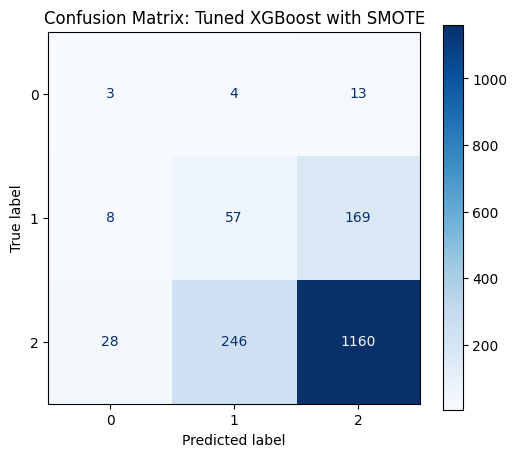

Final test Macro F1-score: 0.3827


In [29]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

tuned_predictions = tuned_model.predict(X_test_final)
print(classification_report(y_test_final, tuned_predictions, zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_final, tuned_predictions, ax=ax, cmap='Blues'
)
ax.set_title('Confusion Matrix: Tuned XGBoost with SMOTE')
plt.show()

print(f'Final test Macro F1-score: {f1_score(y_test_final, tuned_predictions, average="macro"):.4f}')

## 13. Feature importance of the tuned model

Feature importance ranks the selected variables by their contribution to the tuned XGBoost model. The scores explain how the model makes predictions; they do not prove that a variable causes accident severity.

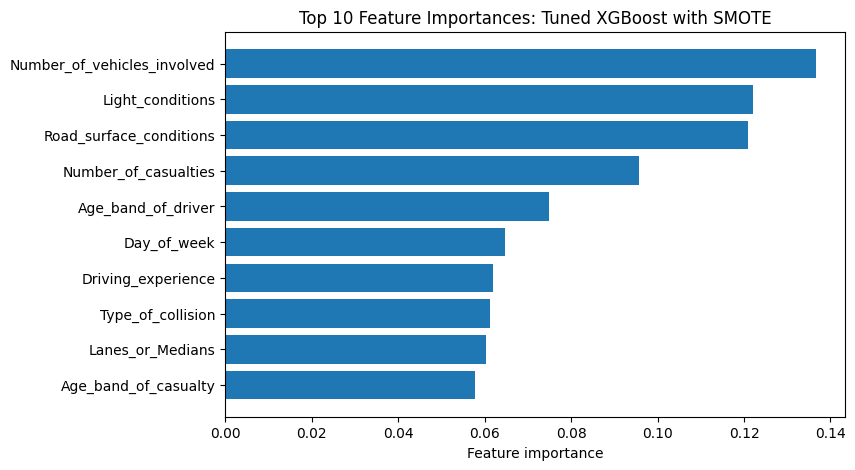

,Feature,Importance
9,Number_of_vehicles_involved,0.136616
5,Light_conditions,0.122158
3,Road_surface_conditions,0.120896
7,Number_of_casualties,0.095603
4,Age_band_of_driver,0.074778
1,Day_of_week,0.064786
11,Driving_experience,0.061941
12,Type_of_collision,0.061171
2,Lanes_or_Medians,0.060303
10,Age_band_of_casualty,0.057766


In [30]:
feature_importance_df = pd.DataFrame({
    'Feature': final_X.columns,
    'Importance': tuned_model.named_steps['model'].feature_importances_
}).sort_values('Importance', ascending=False)

top10_features = feature_importance_df.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top10_features['Feature'][::-1], top10_features['Importance'][::-1])
plt.xlabel('Feature importance')
plt.title('Top 10 Feature Importances: Tuned XGBoost with SMOTE')
plt.show()

top10_features